In [21]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [22]:
class quadraticState(TypedDict):

    a : int
    b : int
    c : int

    equation : str
    discriminant : float
    result : str


In [34]:
def show_equation(state : quadraticState) -> quadraticState:

    equation = f"{state['a']}x2{state['b']}x{state['c']}"

    return {'equation':equation}

In [35]:
def calculate_discriminant(state : quadraticState) -> quadraticState:

    discriminant = (state['b']**2) - 4 * state['a'] * state['c']

    return {'discriminant' : discriminant}


In [36]:
def real_roots(state : quadraticState) -> quadraticState:

    root1 = (-state['b'] + state['discriminant']**0.5)/(2 * state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5)/(2 * state['a'])

    result = f'The real roots are {root1} & {root2}'

    return {'result' : result}


In [37]:
def repeated_roots(state : quadraticState) -> quadraticState:
        
    root = (-state['b'])/(2 * state['a'])

    result = f'The repeated root is {root}'

    return {'result' : result}

In [38]:
def imaginary_roots(state : quadraticState) -> quadraticState:
    
    result = f'No real roots'
    return {'result':result}

In [39]:
# for condition use literal in if/else 

def check_condition(state : quadraticState) -> Literal['real_roots','repeated_roots','imaginary_roots']:

    if state['discriminant'] > 0 :
        return 'real_roots'
    elif state['discriminant'] == 0:
        return 'repeated_roots'
    else:
        return 'imaginary_roots'

In [40]:
graph = StateGraph(quadraticState)

# add nodes
graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discriminant',calculate_discriminant)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_node('imaginary_roots',imaginary_roots)

# add edges
graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant',check_condition)
graph.add_edge('real_roots',END)
graph.add_edge('repeated_roots',END)
graph.add_edge('imaginary_roots',END)

# compile
workflow = graph.compile()

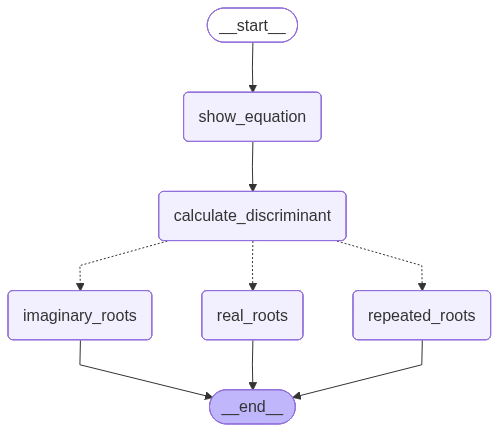

In [41]:
workflow

In [42]:
# execute

initial_state = {
    'a' : 4,
    'b' : -5,
    'c' : -4
}
final_state = workflow.invoke(initial_state)
final_state

{'a': 4,
 'b': -5,
 'c': -4,
 'equation': '4x2-5x-4',
 'discriminant': 89,
 'result': 'The real roots are 1.8042476415070754 & -0.5542476415070754'}